In [1]:
!pip index versions geopandas

geopandas (1.1.1)
Available versions: 1.1.1, 1.1.0, 1.0.1, 1.0.0, 0.14.4, 0.14.3, 0.14.2, 0.14.1, 0.14.0, 0.13.2, 0.13.1, 0.13.0, 0.12.2, 0.12.1, 0.12.0, 0.11.1, 0.11.0, 0.10.2, 0.10.1, 0.10.0, 0.9.0, 0.8.2, 0.8.1, 0.8.0, 0.7.0, 0.6.3, 0.6.2, 0.6.1, 0.6.0, 0.5.1, 0.5.0, 0.4.1, 0.4.0, 0.3.0, 0.2.1, 0.2, 0.1.1, 0.1.0
  INSTALLED: 1.0.1
  LATEST:    1.1.1


In [2]:
!pip install geopandas==1.1.1
!pip install seaborn
!pip install networkx
!pip install scipy

  Attempting uninstall: geopandas
    Found existing installation: geopandas 1.0.1
    Uninstalling geopandas-1.0.1:
      Successfully uninstalled geopandas-1.0.1


In [3]:
# Carga de paquetes necesarios para graficar
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Para leer archivos
import geopandas as gpd # Para hacer cosas geográficas
import seaborn as sns # Para hacer plots lindos
import networkx as nx # Construcción de la red en NetworkX
import funciones.template_funciones as tf
import funciones.template_funciones_dos as tf2

# Preambulo

En esta sección cargamos los datos y los visualizamos. También construimos la matriz de adyacencia de la red de museos.

## Carga de datos de los museos

El listado de los museos, con el que se construye el [mapa](https://mapas.museosabiertos.org/museos/caba/), lo podemos encontrar [acá](https://github.com/MuseosAbiertos/Leaflet-museums-OpenStreetMap/blob/principal/data/export.geojson?short_path=bc357f3). También descargamos los barrios de CABA como complemento para los gráficos.

In [6]:
# Leemos el archivo, retenemos aquellos museos que están en CABA, y descartamos aquellos que no tienen latitud y longitud
museos = gpd.read_file('https://raw.githubusercontent.com/MuseosAbiertos/Leaflet-museums-OpenStreetMap/refs/heads/principal/data/export.geojson')
barrios = gpd.read_file('https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ministerio-de-educacion/barrios/barrios.geojson')

## Visualización

<Axes: >

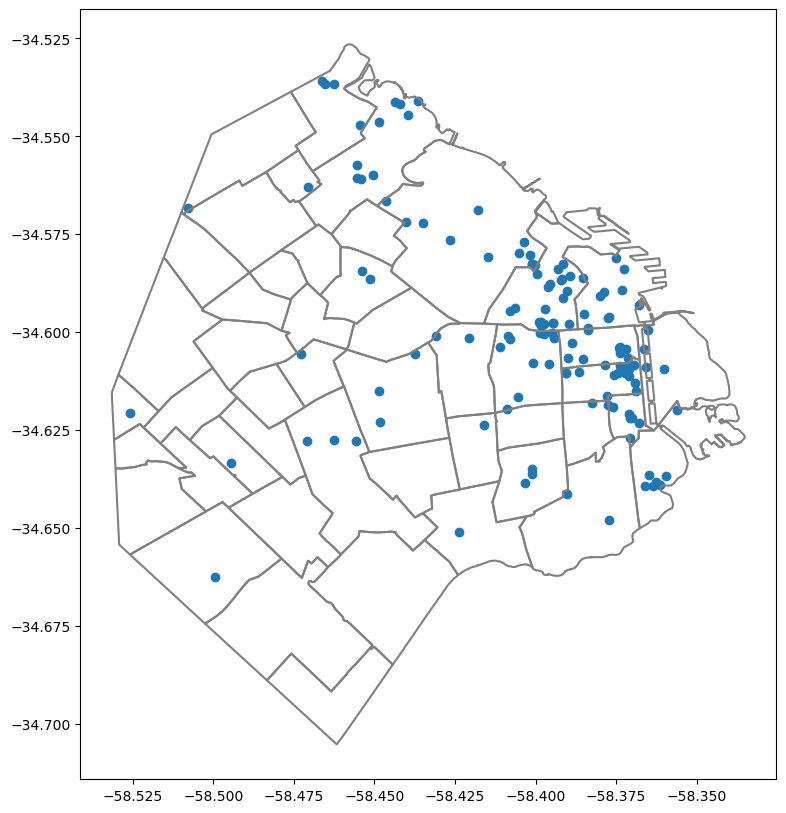

In [8]:
# Armamos el gráfico para visualizar los museos
fig, ax = plt.subplots(figsize=(10, 10))
barrios.boundary.plot(color='gray',ax=ax)
museos.plot(ax=ax)

In [9]:
len(museos)

136

## Cálculo de la matriz de distancias

Ahora construimos la matriz de distancias entre todos los museos. Como la tierra es un [geoide](https://es.wikipedia.org/wiki/Geoide) (es decir que no es [plana](https://es.wikipedia.org/wiki/Terraplanismo)), el cálculo de distancias no es una operación obvia. Una opción es proyectar a un [sistema de coordenadas local](https://geopandas.org/en/stable/docs/user_guide/projections.html), de forma tal que las distancias euclideas se correspondan con las distancias en metros. En este notebook usamos [EPSG](https://en.wikipedia.org/wiki/EPSG_Geodetic_Parameter_Dataset) 22184. 

In [11]:
# En esta línea:
# Tomamos museos, lo convertimos al sistema de coordenadas de interés, extraemos su geometría (los puntos del mapa), 
# calculamos sus distancias a los otros puntos de df, redondeamos (obteniendo distancia en metros), y lo convertimos a un array 2D de numpy
D = museos.to_crs("EPSG:22184").geometry.apply(lambda g: museos.to_crs("EPSG:22184").distance(g)).round().to_numpy()

### Matriz de adyacencia: construimos una matriz conectando a cada museo con los $m$ más cercanos

In [13]:
m = 3 # Cantidad de links por nodo
A = tf.construye_adyacencia(D,m)

## Construcción de la red en NetworkX (sólo para las visualizaciones)

In [15]:
G = nx.from_numpy_array(A) # Construimos la red a partir de la matriz de adyacencia
# Construimos un layout a partir de las coordenadas geográficas
G_layout = {i:v for i,v in enumerate(zip(museos.to_crs("EPSG:22184").get_coordinates()['x'],museos.to_crs("EPSG:22184").get_coordinates()['y']))}

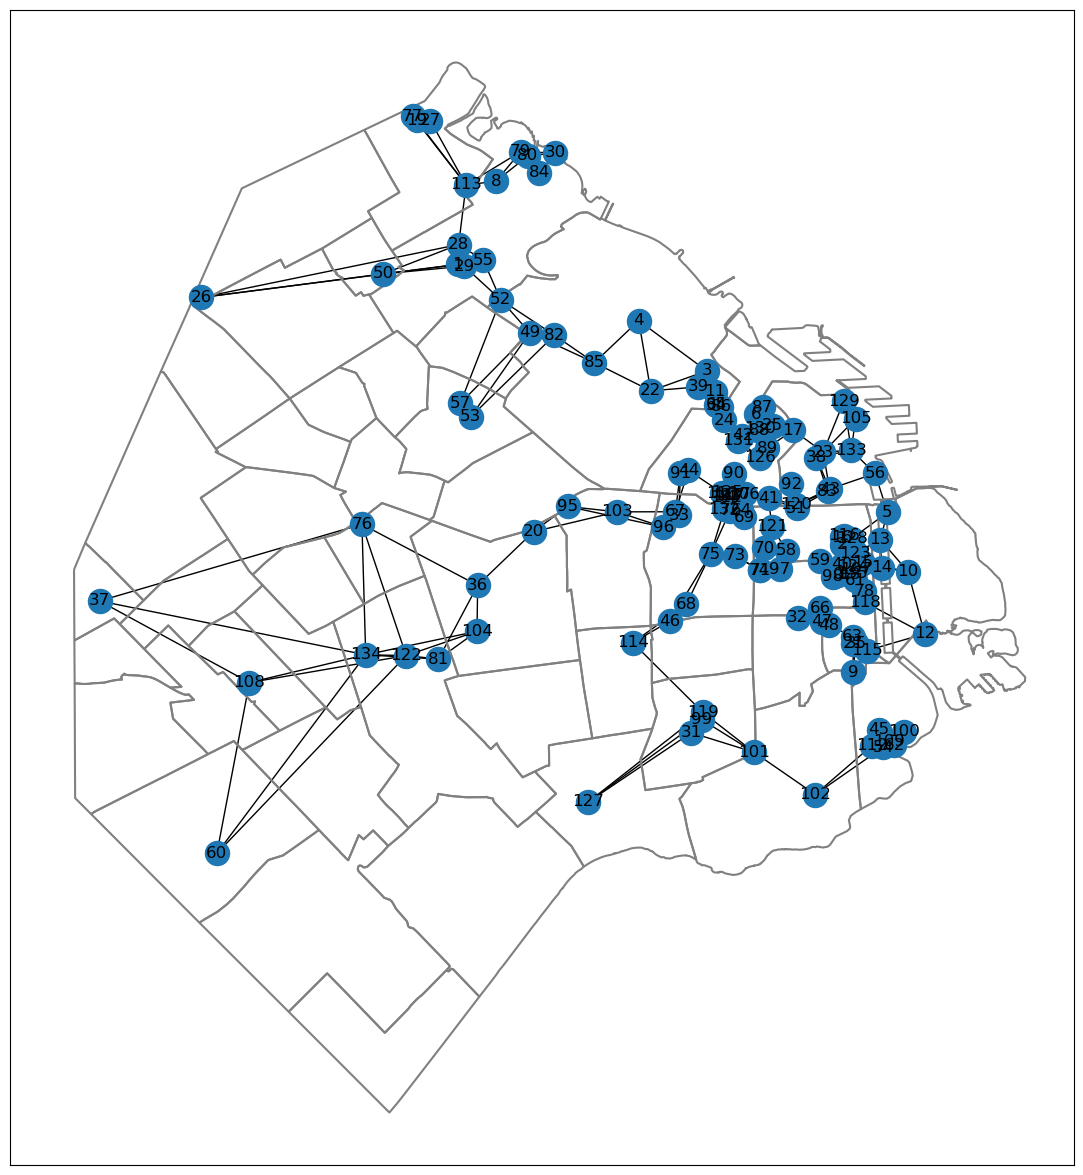

In [16]:
fig, ax = plt.subplots(figsize=(15, 15)) # Visualización de la red en el mapa
barrios.to_crs("EPSG:22184").boundary.plot(color='gray',ax=ax) # Graficamos Los barrios
nx.draw_networkx(G,G_layout,ax=ax) # Graficamos los museos

# Detección de comunidades con métodos espectrales

## Punto 1: autovectores y autovalores de $L$ y $R$

1. Mostrar que el vector de unos 1 es autovector de las matrices R y L.

   > Veamos que tanto $L$ como $R$ tienen autovector $\overset{\rightarrow}{1}$ asociado a $0$.
   >
   > - Con $L$:
   >
   >   $$L = K - A$$
   >
   >   Es una matriz que en la diagonal tiene el grado del nodo i-ésimo y luego $-1$ paras las conexiones, ya que estoy restando la matriz de adyacencia donde tiene ceros en la diagonal.
   >
   >   $$L \begin{pmatrix}1\\ 1\\ \vdots \end{pmatrix} = \text{ da como resultado una matriz que suma las filas}$$
   > 
   >   Cada fila de L, tiene en su elemento correspondiente a la diagonal ($L_{ii} \forall 1 \leq i \leq n$) el elemento $K_{ii} = \sum_{j=1}^n A_{ij}$ por enunciado del TP1. El resto de los elementos de la fila de L, serán los de A con su signo opuesto, por lo tanto, suman $ -\sum_{j=1}^n A_{ij}, \forall 1 \leq i \leq n$.
   > 
   >   Entonces, sumar cada fila de L corresponde a $\sum_{j=1}^n A_{ij} -\sum_{j=1}^n A_{ij} = 0$
   > 
   >   Nos queda que:
   >
   >   $$L. \overset{\rightarrow}{1} = \overset{\rightarrow}{0} = 0 . \overset{\rightarrow}{1} \Rightarrow L \text{ tiene autovector } \overset{\rightarrow}{1} \text{ con autovalor } 0$$
   >
   > - Con $R$:
   >
   >   $$R = A - P$$
   >
   >   Veamos que $R . \overset{\rightarrow}{1} = \lambda. \overset{\rightarrow}{1}$, lo reescribimos: $(A-P)\overset{\rightarrow}{1} = \lambda. \overset{\rightarrow}{1} \leftrightarrow A. \overset{\rightarrow}{1} - P. \overset{\rightarrow}{1} = \lambda. \overset{\rightarrow}{1}$
   >
   >   $$A.\overset{\rightarrow}{1} = \begin{pmatrix}\sum_{j=1}^n A_{1j} = k_{1} \\ \sum_{j=1}^n A_{2j} = k_{2} \\ \vdots \end{pmatrix} = \overset{\rightarrow}{k}$$
   >
   >   $$P. \overset{\rightarrow}{1} = \begin{pmatrix} \frac{k_1k_1}{2E} & \cdots & \frac{k_1k_n}{2E} \\ \vdots & \ddots & \vdots \\ \frac{k_nk_1}{2E} & \cdots & \frac{k_nk_n}{2E}\end{pmatrix} \begin{pmatrix}1 \\ 1 \\ \vdots \end{pmatrix} = \begin{pmatrix} \frac{k_1 (k_1 + \cdots + k_n)}{2E} \\ \vdots \\ \frac{k_n (k_1 + \cdots + k_n)}{2E} \end{pmatrix} = \begin{pmatrix} \frac{k_i}{2E}\sum_{j=1}^n  k_j \\ \vdots \\ \frac{k_n}{2E}\sum_{j=1}^n k_j \end{pmatrix} \overset{\sum_{j=1}^n k_j = 2E}{\Rightarrow} \begin{pmatrix} \frac{k_i}{\cancel{2E}}\cancel{\sum_{j=1}^n  k_j}\\ \vdots \\ \frac{k_n}{\cancel{2E}}\cancel{\sum_{j=1}^n k_j} \end{pmatrix} = \overset{\rightarrow}{k}$$
   >
   >   $$\Rightarrow A.\overset{\rightarrow}{1} - P. \overset{\rightarrow}{1} = \overset{\rightarrow}{k} - \overset{\rightarrow}{k} = 0$$

   ¿Qué autovalor tiene?

   > El autovalor asociado al autovector de $\overset{\rightarrow}{1}$ es $0$ tanto para $R$ y $L$

   ¿Y qué agrupación de la red representa?

   > Representa la agrupación donde todos los museos son del mismo grupo.

---

2. mostrar que si $L (R)$ tienen dos autovectores $v_1$ y $v_2$ asociados a autovalores $\lambda_1 \neq \lambda_2$, entonces $v_1^t v_2 = 0$

   > Consideramos una matriz $M$ simétrica con dos autovectores $v_1$ y $v_2$ con autovalores distintos $\lambda_1$ y $\lambda_2$. Y hacemos las siguientes operaciones:
   >
   > Sabemos que:
   > - $v_1^t M = v_1^t \lambda_1$
   > - $v_2^t M= v_2^t \lambda_2$
   >
   > Multiplicando $v_1$ y $v_2$ de manera "cruzada" obtenemos:
   > 
   > - $v_1^t M v_2= v_1^t \lambda_1 v_2$
   > - $v_2^t M v_1 = v_2^t \lambda_2 v_1$
   >
   > Como $v_1^t M v_2$ es un número real, es igual a su traspuesta:
   > $(v_1^t M v_2)^t = (v_2^t M^t v_1) = (v_2^t M v_1)$ pues M es simétrica
   >
   > Como $(v_1^t M v_2)^t = (v_2^t M v_1)$, podemos restar:
   >
   > $$v_2^t \lambda_2 v_1 - v_2^t \lambda_1 v_1 = 0$$
   >
   > $$v_2^t v_1 ( \lambda_1 - \lambda_2) = 0$$
   >
   > Como $\lambda_1 \neq \lambda_2 \Rightarrow v_2^t v_1 = 0$
   >
   > Esto se cumple para cualquier matriz simétrica, en particular para L.
   
---

3. Mostrar si $v$ es un autovector de autovalor $\lambda \neq 0$ de $R$ o $L$, entonces $\sum_i v_i = 0$

   > Sea $v$ un autovector de $L$ o $R$ con autovalor $\lambda \neq 0$. Como estas matrices son simétricas, admiten una base ortonormal de autovectores. Ya demostramos que $\overset{\rightarrow}{1}$ es un autovector con autovalor $0$, y que los autovectores asociados a autovalores distintos son ortogonales.
   >
   > $$\Rightarrow v \perp \overset{\rightarrow}{1} \Rightarrow \overset{\rightarrow}{1}^t v = \sum_i v_i = 0 $$

## Punto 2: extensiones del método de la potencia

Consideramos una matriz $M \in \mathbb{R}^{n\times n}$ diagonalizable con autovalores $\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_n$, y autovector $v_i$ asociado a $\lambda_i$

1. **Shifting de autovalores**: Muestre que los autovalores de $M+μI$ son $γ_i = λ_i+μ$, y que el autovector asociado a $γ_i$ es $v_i$. Concluya que si $μ + λ_i \neq 0 ∀i$, entonces $M + μI$ es inversible.

   > Sea $v_i$ un autovector de $M$ asociado a $\lambda_1$:
   >
   > $$Mv_i = \lambda_i v_i $$
   >
   > Sumamos $\mu I$:
   >
   > $$(M+\mu I)v_i = M v_i+\mu I v_i = \lambda_i v_i + \mu v_i = (\lambda_i + \mu) v_i$$
   >
   > $\Rightarrow v_i$ es autovector de $M+\mu I$ con autovalor $\gamma = \lambda_i + \mu$
   >
   > Si $\lambda_i + \mu \neq 0 \forall i$, entonces los autovalores $\gamma_i$ son distintos de cero.
   > Entonces, no existe vector en el núcleo de $M +\mu I$ porque si existiera sería un autovector asociado a un autovalor 0, lo cual contradice lo anterior.
   >
   > $$0 \notin \{\gamma_i\} = \{\lambda_i + \mu\} \Rightarrow \lambda_i + \mu \neq 0 \forall i \Rightarrow M + \mu I \text{ es invertible}$$
   

2. **Método de la potencia inverso**: Considerando $\mu > 0$, muestren que $L + \mu I$ es inversible, con $L$ el laplaciano definido en la ecuación $L = K-A$.

    > Sabemos que la matriz $L$ es el laplaciano (que es simétrica y semidefinida positiva) por lo tanto sus autovalores son:
    >
    > $$\lambda_1 = 0 \leq \lambda_2 \leq \cdots \leq \lambda_n$$
    >
    > Sumado al hecho que $\mu > 0$ es el shifting del espectro, nos queda que los autovalores de $L+\mu I$ son $\lambda_i + \mu > 0$. Y como todos los autovalores de $L+\mu I$ son estrictamente positivos, por lo que sabemos del inciso anterior, concluimos:
    >
    > $$\Rightarrow L + \mu I \text{ es invertible }$$

    Muestren que aplicar el método de la potencia a $(L + \mu I)^{−1}$ converge a su autovector de autovalor más chico si se parte de una semilla adecuada. Indique, en el caso de que hay sólo un autovector con dicho autovalor, cuál es dicho autovector y cuánto vale su autovalor.

    > Si $Lv_i = \lambda_i v_i$, entonces:
    >
    > $$(L + \mu I)v_i = (\lambda_i + \mu) v_i \Rightarrow (L + \mu I)^{-1} v_i = \frac{1}{(\lambda_i + \mu)} v_i $$
    >
    > O sea, los autovectores son los mismos, pero ahora los autovalores son $\frac{1}{(\lambda_i + \mu)}$
    >
    > Como anteriormente teniamos que $\lambda_1 = 0 \leq \lambda_2 \leq \cdots \leq \lambda_n$, ahora pasamos a:
    >
    > $$\frac{1}{\lambda_1 + \mu} = \frac{1}{\mu} > \frac{1}{\lambda_2 + \mu} > \cdots$$
    >
    > Como el método de la potencia converge al autovector asociado al mayor autovalor, en este caso es el autovector asociado al autovalor $\frac{1}{\mu}$ que a su vezes el autovector asociado al autovalor $\lambda = 0$ de $L$, es decir $\overset{\rightarrow}{1}$
    
3. **Deflación de Hotelling**: suponiendo que $M$ es simétrica (y por lo tanto admite una base ortogonal de autovectores), muestre que la matriz $\overset{\sim}{M} - \lambda_1 \frac{v_1 v_1^t}{v_1^t v_1}$ tiene los mismos autovectores que $M$, pero el autovalor asociado a $v_1$ es igual a cero.

    > La deflación de Hotelling consiste en:
    >
    > $$\overset{\sim}{M} = M - \lambda_1 \frac{v_1 v_1^t}{v_1^t v_1}$$
    >
    > Donde a $M$ le resto $\frac{v_1 v_1^t}{v_1^t v_1}$ que es la proyección ortogonal sobre el subespacio generado por $v_1$
    >
    > - Veamos autovector $v_1$:
    >
    >    Qué pasa si aplicamos $\overset{\sim}{M}$ a $v_1$
    >
    >    $$\overset{\sim}{M} v_1 = \bigg( M - \lambda_1 \frac{v_1 v_1^t}{v_1^t v_1} \bigg) v_1 = M v_1 - \lambda_1 \frac{v_1 v_1^t v_1}{v_1^t v_1} $$
    >
    >    Usamos que $M v_1 = \lambda_1 v_1$ y también que $v_1^t v_1 = \langle v_1, v_1 \rangle$ (o sea, que es un número). Entonces nos queda:
    >
    >    $$\overset{\sim}{M} v_1 = \lambda_1 v_1 - \lambda_1 \frac{v_1 \cancel{(v_1^t v_1)}}{\cancel{v_1^t v_1}} = 0$$
    >
    >    Por lo tanto el autovalor asociado a $v_1$ es $0$
    >
    > - Veamos autovectores ortogonales a $v_1$:
    >
    >   Sea $v_k$ otro autovector de $M$, con $\lambda_k \neq \lambda_1$ y pasa que $v_k^t v_1 = 0$ por ortogonalidad de autovectores de matrices simétricas.
    >
    >   Veamos qué pasa cuando le aplicamos $\overset{\sim}{M}$ a $v_k$
    >
    >   $$\overset{\sim}{M}v_k = Mv_k - \lambda_1 \frac{v_1 v_1^t v_k}{v_1^t v_1}$$
    >
    >   Pero como $v_1^t v_k = 0$, entonces:
    >
    >   $$\overset{\sim}{M} = M v_k - 0 = \lambda_k v_k $$
    >
    >   $\Rightarrow v_k$ sigue siendo autovector y su autovalor no cambia.

## Punto 3: implementación computacional

In [21]:
A_ejemplo = np.array([
   [0, 1, 1, 1, 0, 0, 0, 0],
   [1, 0, 1, 1, 0, 0, 0, 0],
   [1, 1, 0, 1, 0, 1, 0, 0],
   [1, 1, 1, 0, 1, 0, 0, 0],
   [0, 0, 0, 1, 0, 1, 1, 1],
   [0, 0, 1, 0, 1, 0, 1, 1],
   [0, 0, 0, 0, 1, 1, 0, 1],
   [0, 0, 0, 0, 1, 1, 1, 0]
])


In [22]:
comunidades_laplaciano = tf2.laplaciano_iterativo(A_ejemplo, niveles=2)
print("Partición en 4 grupos (Laplaciano):", comunidades_laplaciano)


Partición en 4 grupos (Laplaciano): [[4, 7], [5, 6], [0, 3], [1, 2]]


In [23]:
comunidades_modularidad = tf2.modularidad_iterativo(A=A_ejemplo)
print("Partición óptima (Modularidad):", comunidades_modularidad)


Partición óptima (Modularidad): [[4, 5, 6, 7], [0, 1, 2, 3]]


**Partición óptima en 4 grupos usando el método basado en el Laplaciano:**

Aplicando la función `laplaciano_iterativo` al grafo de la Figura 1 con `niveles = 2`, obtenemos la siguiente partición en 4 comunidades:

[4, 7], [5, 6], [0, 3], [1, 2]

Lo cual correspone a agrupar: (5, 8), (6, 7), (1, 4), (2, 3) realizando 9 cortes en el grafo de ejemplo del enunciado.


---

**Partición óptima basada en la Modularidad:**

Aplicando la función `modularidad_iterativo`, obtenemos la siguiente partición:

[4, 5, 6, 7], [0, 1, 2, 3]


Esta segmentación separa claramente los dos grupos más densamente conectados, maximizando la modularidad total del grafo. En este caso, el algoritmo decidió no subdividir más porque no se mejoraba la métrica de modularidad.


## Punto 4: análisis gráfico

### 4.1 Modularidad

In [26]:
for m in [3, 5, 10, 50]:
    A = tf.construye_adyacencia(D, m)
    A_simetrica = np.ceil(1/2 * (A + A.T))
    comunidades_m = tf2.modularidad_iterativo(A_simetrica, None, None)
    print(f'Con m = {m} y utilizando modularidad, las comunidades resultan: {len(comunidades_m)}')

Con m = 3 y utilizando modularidad, las comunidades resultan: 14
Con m = 5 y utilizando modularidad, las comunidades resultan: 10
Con m = 10 y utilizando modularidad, las comunidades resultan: 6
Con m = 50 y utilizando modularidad, las comunidades resultan: 2


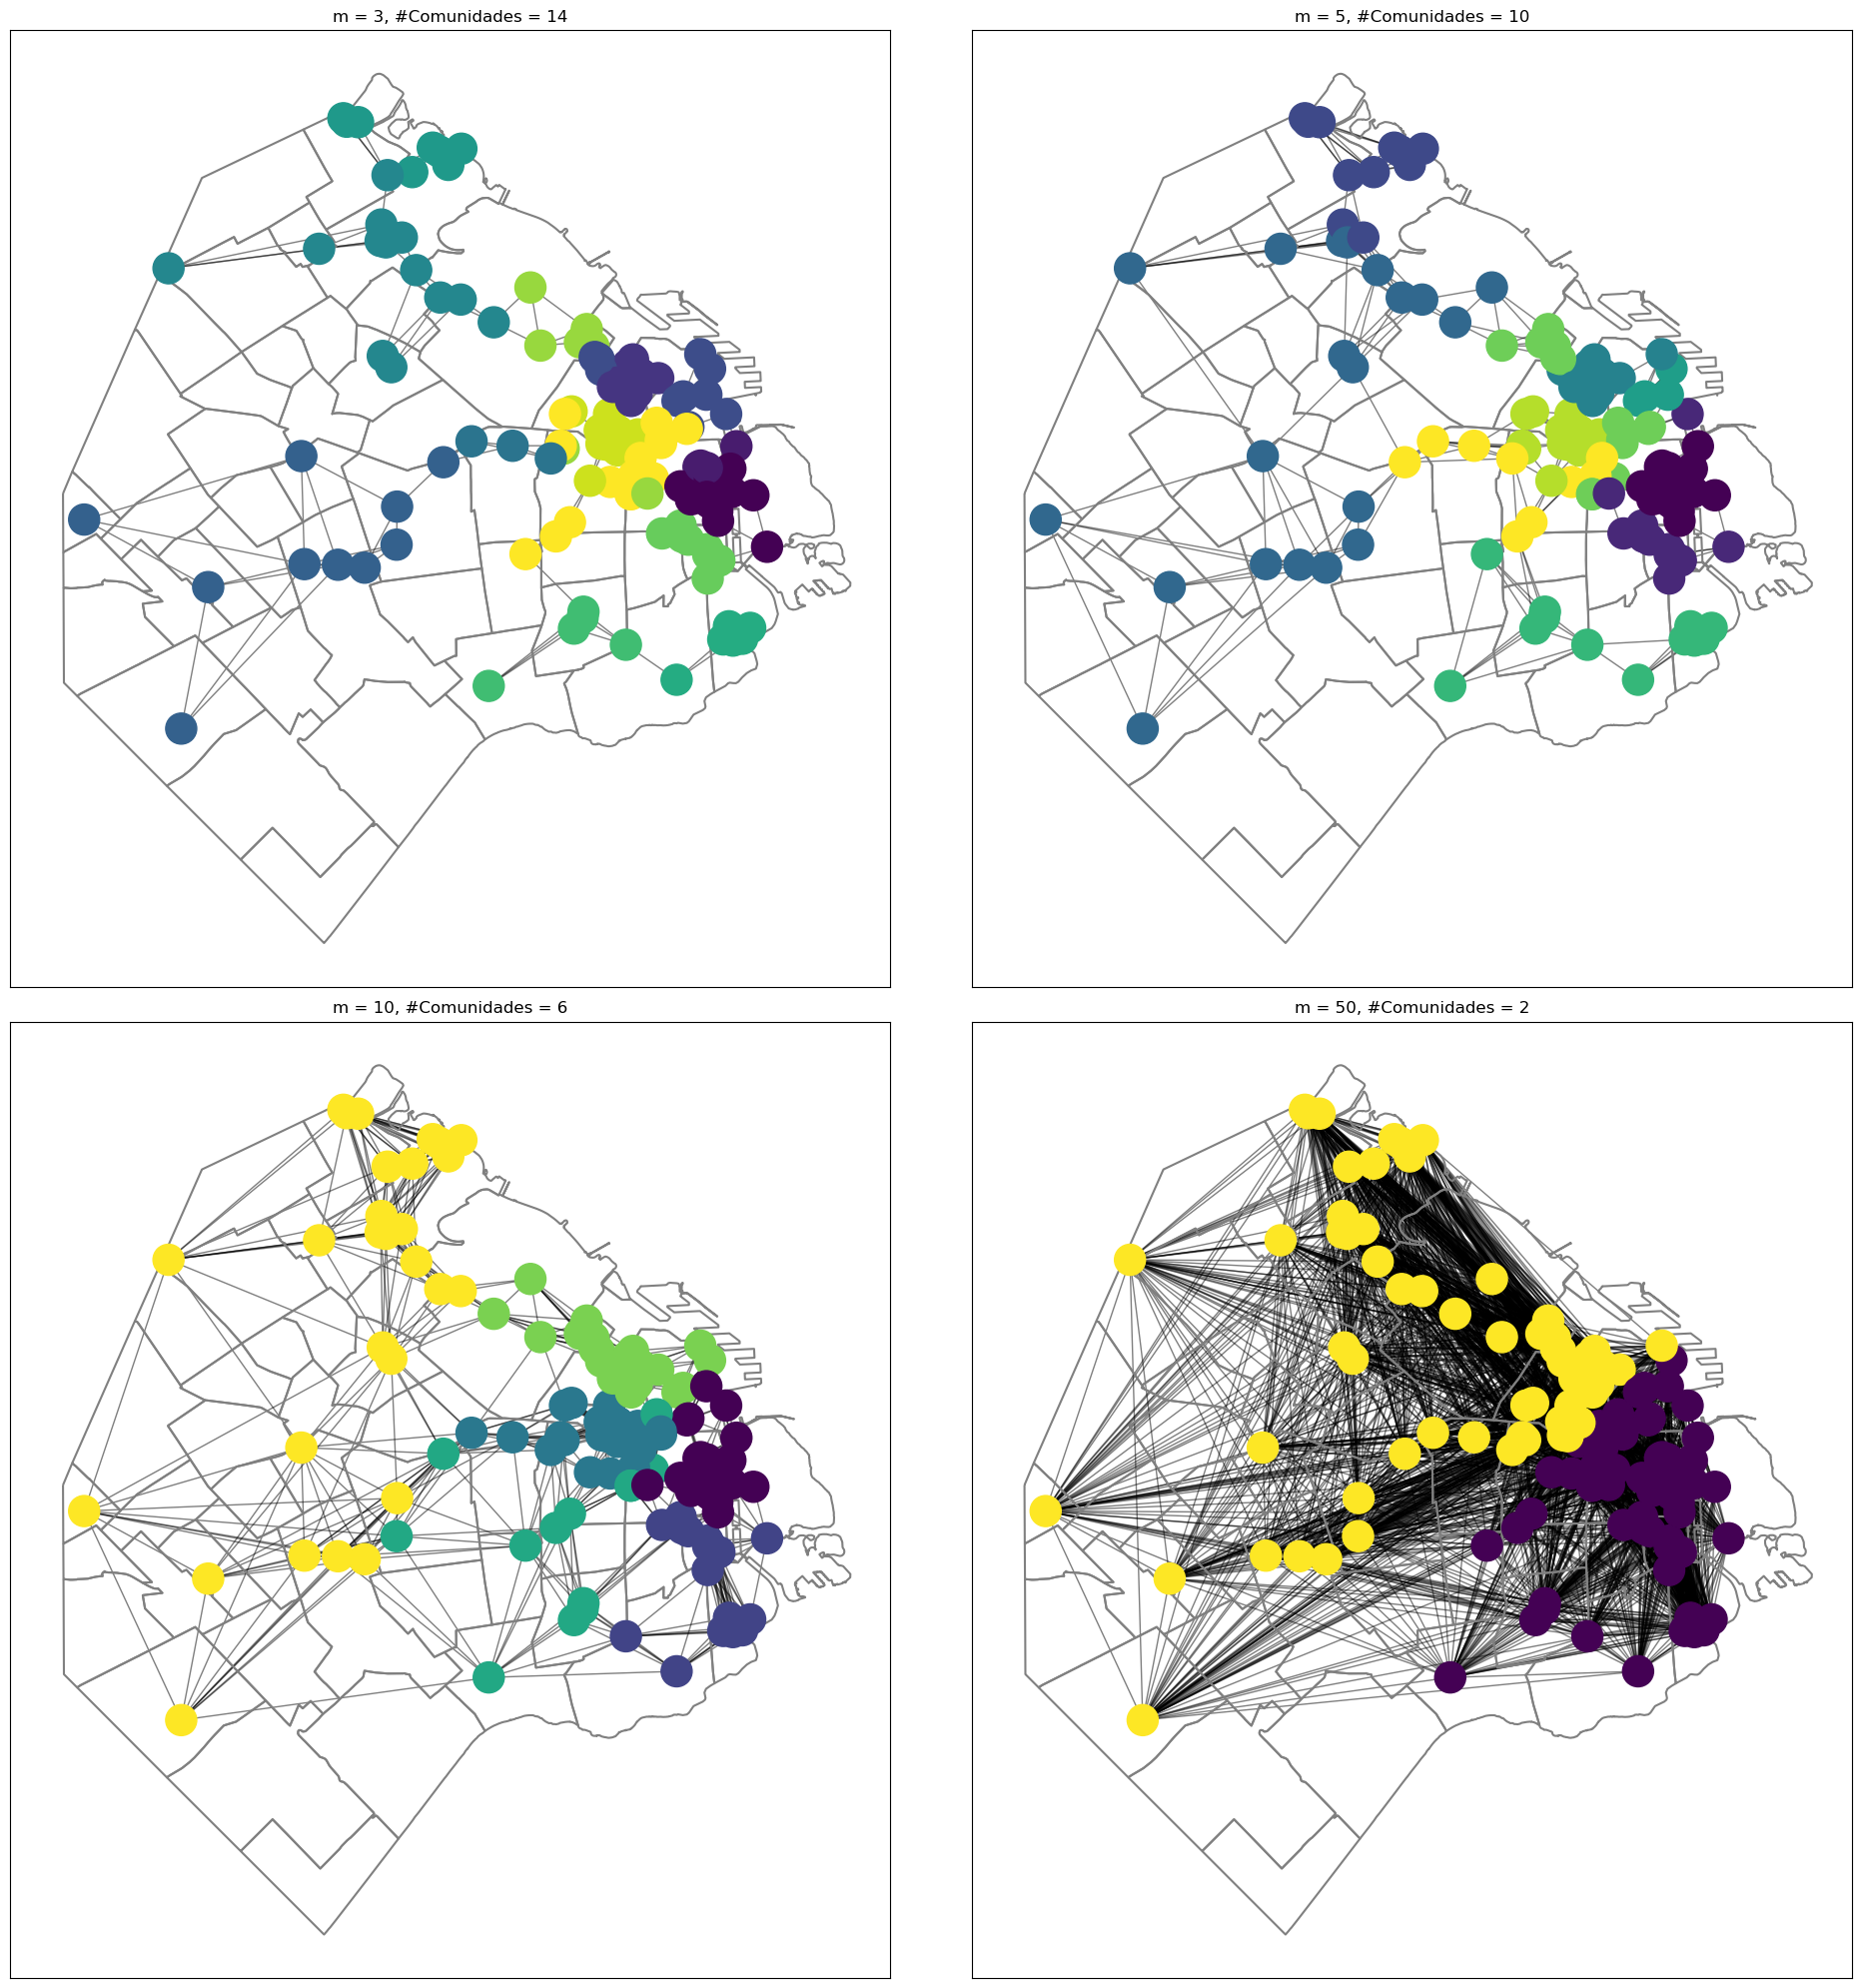

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
m_values = [3, 5, 10, 50]

# Creamos un grafico por espacio en el grid
for ax, m in zip(axes.flat, m_values):
    A = tf.construye_adyacencia(D, m)
    A_simetrica = np.ceil(1/2 * (A + A.T))
    comunidades_m = tf2.modularidad_iterativo(A_simetrica, None, None)

    coloreo = np.zeros(A_simetrica.shape[0], dtype=int)
    for i, comunidad in enumerate(comunidades_m):
        for museo in comunidad:
            coloreo[museo] = i

    G = nx.from_numpy_array(A) # Construimos la red a partir de la matrix de adyacencia

    # Construimos un layout a partir de las coordenadas geograficas
    G_layout = {i:v for i,v in enumerate(zip(museos.to_crs("EPSG:22184").get_coordinates()['x'],museos.to_crs("EPSG:22184").get_coordinates()['y']))}

    barrios.to_crs("EPSG:22184").boundary.plot(color='gray',ax=ax) # Graficamos Los barrios

    # cmap para mapear los colores con matplotlib
    nodes = nx.draw_networkx_nodes(G, G_layout, node_color=coloreo, cmap=plt.cm.viridis, ax=ax, node_size=500)
    nx.draw_networkx_edges(G, G_layout, ax=ax, alpha=0.5)
    # nx.draw_networkx_labels(G, G_layout, ax=ax, labels={i: f"{p[i]:.2f}" for i in range(D.shape[0])}, font_size=6) # num de museo

    ax.set_title(f'm = {m}, #Comunidades = {len(comunidades_m)}')

plt.tight_layout()
plt.show()

Separando por modularidad, la cantidad de conexiones (m) propuesta afectaba la cantidad de comunidades.

- Con m = 3, obtuvimos 14 comunidades en general medianamente distinguibles.

- Con m = 5, las comunidades se reducen a 10, todavía algunas visiblemente "solapadas".

- Con m = 10, obtuvimos 6 comunidades ya mejor separadas en el mapa.

- Con m = 50, sólo se tienen 2 comunidades fuertemente conectadas que dividen el mapa en dos por consistir en museos muy cercanos entre sí.

### 4.2 Corte Mínimo

Como la elección de los niveles para el método del laplaciano corresponde a encontrar $2^{niveles}$ comunidades,
decidimos usar el m correspondiente a cada gráfico de modularidad, y con cantidad de niveles = 4, 3 , 2, 1 para obtener
comunidades similares: 16, 8, 4 ,2.

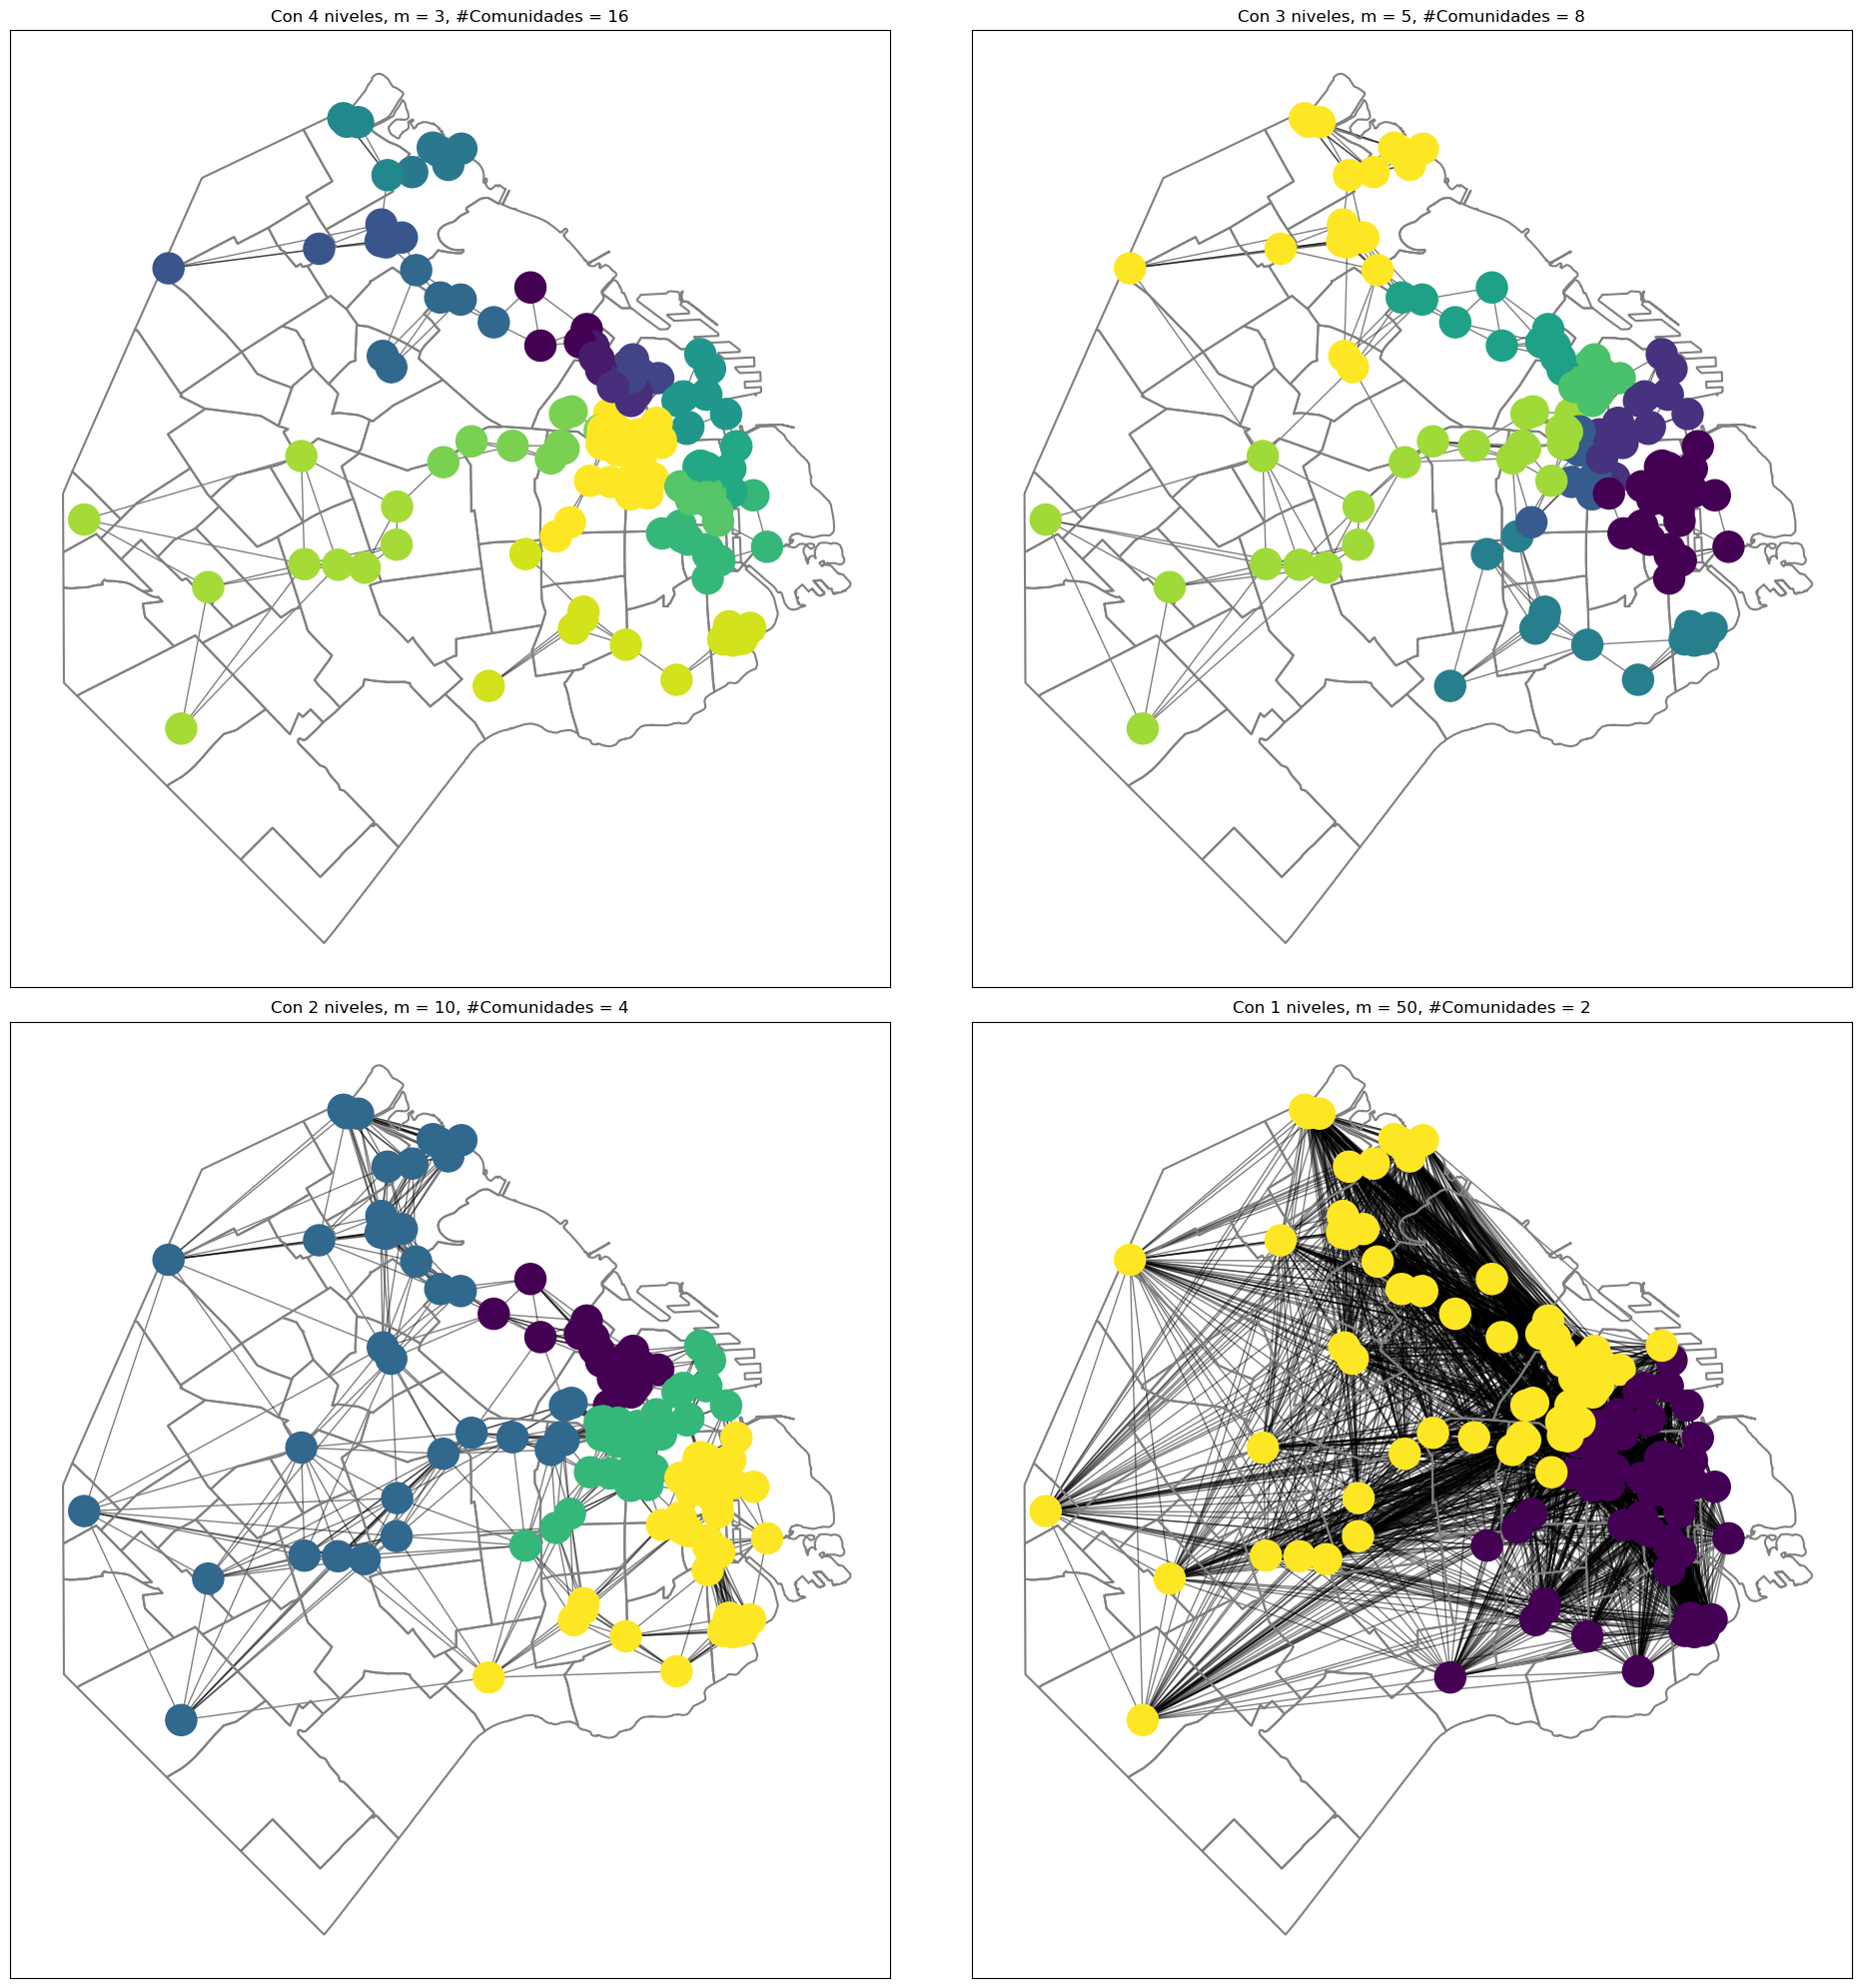

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
m_niv = [(3, 4), (5, 3), (10, 2), (50, 1)]

# Creamos un grafico por espacio en el grid
for ax, (m_, n_) in zip(axes.flat, m_niv):
    A = tf.construye_adyacencia(D, m_)
    A_simetrica = np.ceil(1/2 * (A + A.T))
    comunidades_m = tf2.laplaciano_iterativo(A_simetrica, n_)

    coloreo = np.zeros(A_simetrica.shape[0], dtype=int)
    for i, comunidad in enumerate(comunidades_m):
        for museo in comunidad:
            coloreo[museo] = i

    G = nx.from_numpy_array(A) # Construimos la red a partir de la matrix de adyacencia

    # Construimos un layout a partir de las coordenadas geograficas
    G_layout = {i:v for i,v in enumerate(zip(museos.to_crs("EPSG:22184").get_coordinates()['x'],museos.to_crs("EPSG:22184").get_coordinates()['y']))}

    barrios.to_crs("EPSG:22184").boundary.plot(color='gray',ax=ax) # Graficamos Los barrios

    # cmap para mapear los colores con matplotlib
    nodes = nx.draw_networkx_nodes(G, G_layout, node_color=coloreo, cmap=plt.cm.viridis, ax=ax, node_size=500) # Adjust node_size as needed
    nx.draw_networkx_edges(G, G_layout, ax=ax, alpha=0.5)
    #nx.draw_networkx_labels(G, G_layout, ax=ax, labels={i: f"{p[i]:.2f}" for i in range(D.shape[0])}, font_size=6) # num de museo

    ax.set_title(f'Con {n_} niveles, m = {m_}, #Comunidades = {len(comunidades_m)}')

plt.tight_layout()
plt.show()

Con el método del Laplaciado, obtuvimos la cantidad esperada de comunidades y comparando con las obtenidas con Modularidad,
si bien a niveles generales resultan muy parecidas en cantidad y distribución,
de todas formas, podemos notar que en el Laplaciano los límites de las comunidades están mejor definidos mezclándose menos.

# Punto 5: Síntesis

En el presente trabajo nos propusieron explorar la distribución de museos de la Ciudad Autónoma de Buenos Aires teniendo a disposición dos datasets: uno de museos y otro de barrios.

Primero comenzamos explorando los datasets provistos:
- En "museos" notamos la inclusión de la librería geopandas que nos aportaba los POINTS para conocer la ubicación precisa de cada museo. No utilizamos las demás variables en general pues preferimos distinguir a los museos según su ubicación en el dataframe. Conocimos la librería NetworkX que terminaba de ubicar los nodos en las figuras.
- En "barrios" se distribuían los lugares de CABA para terminar de dibujar el mapa.

Para la primera parte del trabajo, el objetivo era poder ordenar los museos según la elección que hicieran visitantes en, por ejemplo, La Noche de los Museos. Mediante el uso de técnicas de descomposición de matrices (LU), pudimos invertir matrices, calcular el número de condición y armar programas que efectivamente ordenaran los museos. Era natural para nosotros pensar que la cercanía siempre jugaría a favor de los museos para ordenarse, y nos sorprendimos con la inclusión del factor de aleatoriedad y que luego mediante gráficos pudimos reflexionar en cuanto a que si los visitantes se moviesen completamente al azar, la cercanía de los museos ya no resultaba importante. Fue también sorprendente enterarnos que este problema de ordenar museos o realizar un ranking, es un problema muy estudiado o con muchas aplicaciones.

Sucesivamente, en la segunda parte del trabajo, continuamos trabajando con la misma disposición de museos. Nos interesó poder pensar y usar herramientas teóricas que discutíamos en clase, puesto que las matrices que usamos en el primer trabajo, ahora las hacíamos simétricas para tener más propiedades o aplicar algoritmos útiles. Con una matriz simétrica como la del trabajo, teníamos también una base ortonormal de autovectores y eso nos permitió aplicar la deflación de Hotelling. Sobre esto último, destacamos que nos sirvió mucho las discusiones en el laboratorio para poder entender las ideas detrás de las fórmulas, o cómo asociar el tener autovectores/ autovalores a nuestras agrupaciones. Ante errores en los códigos volvíamos a la teoría y ante dudas con la teoría probábamos código. Armamos algoritmos para el método de la potencia y sus variantes, deflación y agrupamientos, vectorizando y usando los algoritmos ya armados. Agrupamos por corte mínimo y modularidad usando todo lo anterior y nos enriqueció mucho poder ver dichas particiones gráficamente para luego discutirlas.